In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('/content/placement.csv')

In [9]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [12]:
df.shape

(100, 4)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


## Steps
0. Preprocess + EDA + Feature selection
1. Extract input and output cols
2. Scale the values
3. train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [17]:
df = df.iloc[:,1:]

In [20]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [21]:
import matplotlib.pyplot as plt

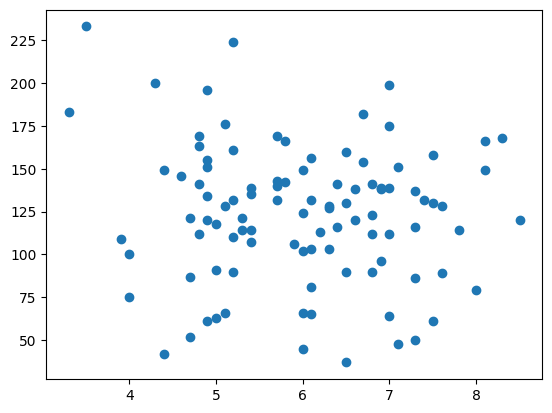

In [24]:
plt.scatter(df['cgpa'],df['iq'])

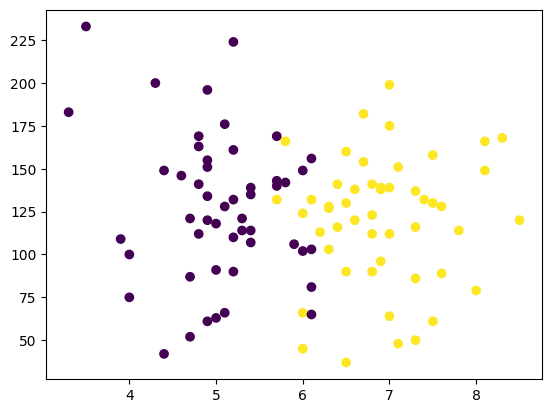

In [25]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [26]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [27]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [28]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [29]:
x.shape

(100, 2)

In [30]:
y.shape

(100,)

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [33]:
x_train

,cgpa,iq
40,4.9,134.0
10,6.0,45.0
85,5.8,166.0
98,6.3,103.0
24,4.7,121.0
...,...,...
60,6.9,139.0
74,6.7,154.0
73,4.9,61.0
49,5.4,135.0


In [34]:
y_train

,placement
40,0
10,1
85,1
98,1
24,0
...,...
60,1
74,1
73,0
49,0


In [36]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
x_train = scaler.fit_transform(x_train)

In [40]:
x_train

array([[-0.90096112,  0.26356804],
       [ 0.05096151, -2.0462569 ],
       [-0.12211533,  1.0940669 ],
       [ 0.31057678, -0.54097773],
       [-1.07403797, -0.07382212],
       [ 0.91634573,  1.3276447 ],
       [-0.72788428, -1.50124203],
       [ 0.65673047,  1.50931632],
       [ 1.34903784,  0.88644218],
       [ 0.48365362,  0.15975568],
       [-0.20865375,  0.41928658],
       [-0.64134586,  2.59934607],
       [ 0.91634573, -0.30739992],
       [ 1.86826837,  0.65286438],
       [-0.90096112, -0.09977521],
       [ 0.91634573,  0.39333349],
       [ 1.34903784,  0.15975568],
       [ 0.74326889, -0.87836789],
       [-0.90096112,  0.80858291],
       [-0.98749954,  1.17192616],
       [-0.64134586,  0.21166186],
       [-0.03557691, -0.46311846],
       [ 0.05096151,  0.65286438],
       [ 0.13749994, -1.52719512],
       [ 0.74326889, -0.30739992],
       [ 0.3971152 , -0.20358757],
       [ 1.00288415,  0.70477056],
       [-0.46826901,  0.39333349],
       [-0.46826901,

In [41]:
x_test = scaler.transform(x_test)

In [42]:
x_test

array([[-0.20865375,  1.17192616],
       [-0.55480744, -0.25549375],
       [-0.90096112,  0.70477056],
       [ 0.48365362, -0.87836789],
       [ 0.48365362,  0.93834836],
       [ 0.48365362, -2.25388162],
       [ 1.43557626,  0.1078495 ],
       [ 1.17596099, -0.20358757],
       [ 0.91634573,  1.95051884],
       [ 1.00288415, -1.96839764]])

In [43]:
from sklearn.linear_model import LogisticRegression

In [45]:
clf = LogisticRegression()

In [47]:
# model_training
clf.fit(x_train,y_train)

LogisticRegression()

In [50]:
y_pred = clf.predict(x_test)

In [51]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [49]:
y_test

,placement
84,0
46,0
89,0
79,1
38,1
82,1
30,1
72,1
26,1
5,1


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test,y_pred)

1.0

In [54]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

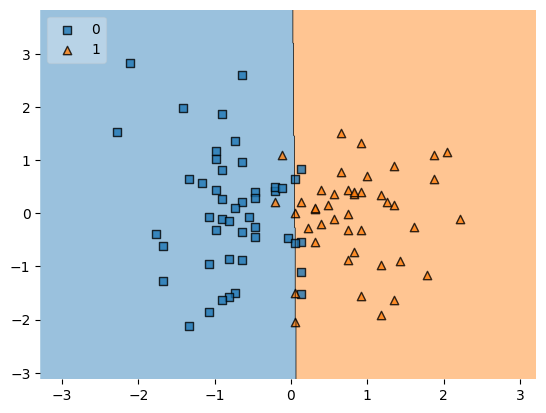

In [56]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [57]:
import pickle

In [58]:
pickle.dump(clf,open('model.pkl','wb'))